In [ ]:
# Install required packages
!pip install datasets transformers imbalanced-learn nltk torch matplotlib

In [ ]:
# Upgrade specific packages
!pip install --upgrade transformers datasets accelerate

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from imblearn.over_sampling import SMOTE

In [ ]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Load datasets
train_df = pd.read_csv('/content/twitter_training.csv', header=None, names=['id', 'company', 'class', 'tweet'])
validation_df = pd.read_csv('/content/twitter_validation.csv', header=None, names=['id', 'company', 'class', 'tweet'])

In [ ]:
# Print columns to check if they are correctly loaded
print(train_df.columns)
print(validation_df.columns)

Index(['id', 'company', 'class', 'tweet'], dtype='object')
Index(['id', 'company', 'class', 'tweet'], dtype='object')


In [ ]:
train_df

,id,company,class,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       74682 non-null  int64 
 1   company  74682 non-null  object
 2   class    74682 non-null  object
 3   tweet    73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
validation_df

,id,company,class,tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
validation_df.info

<bound method DataFrame.info of        id              company       class  \
0    3364             Facebook  Irrelevant   
1     352               Amazon     Neutral   
2    8312            Microsoft    Negative   
3    4371                CS-GO    Negative   
4    4433               Google     Neutral   
..    ...                  ...         ...   
995  4891  GrandTheftAuto(GTA)  Irrelevant   
996  4359                CS-GO  Irrelevant   
997  2652          Borderlands    Positive   
998  8069            Microsoft    Positive   
999  6960      johnson&johnson     Neutral   

                                                 tweet  
0    I mentioned on Facebook that I was struggling ...  
1    BBC News - Amazon boss Jeff Bezos rejects clai...  
2    @Microsoft Why do I pay for WORD when it funct...  
3    CSGO matchmaking is so full of closet hacking,...  
4    Now the President is slapping Americans in the...  
..                                                 ...  
995  ⭐️ Toronto is the arts and culture capital of ...  
996  tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...  
997  Today sucked so it’s time to drink wine n play...  
998  Bought a fraction of Microsoft today. Small wins.  
999  Johnson & Johnson to stop selling talc baby po...  

[1000 rows x 4 columns]>

In [ ]:
# Rename columns for consistency
columns = ['tweet_id', 'entity', 'sentiment', 'tweet_content']
train_df.columns = columns
validation_df.columns = columns

In [ ]:
# Drop rows with missing values
train_df.dropna(inplace=True)
validation_df.dropna(inplace=True)

In [ ]:
# Check shapes and missing values
print(train_df.shape)
print(validation_df.shape)
print(train_df.isnull().sum())
print(validation_df.isnull().sum())

(73996, 4)
(1000, 4)
tweet_id         0
entity           0
sentiment        0
tweet_content    0
dtype: int64
tweet_id         0
entity           0
sentiment        0
tweet_content    0
dtype: int64


In [ ]:
# Filter for Microsoft tweets
train_df = train_df[train_df['entity'] == 'Microsoft']
validation_df = validation_df[validation_df['entity'] == 'Microsoft']

In [ ]:
# Clean and preprocess text
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    return text

train_df['tweet_content'] = train_df['tweet_content'].apply(clean_text)
validation_df['tweet_content'] = validation_df['tweet_content'].apply(clean_text)

<ipython-input-20-607375cfffbe>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['tweet_content'] = train_df['tweet_content'].apply(clean_text)
<ipython-input-20-607375cfffbe>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df['tweet_content'] = validation_df['tweet_content'].apply(clean_text)


In [ ]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])

train_df['tweet_content'] = train_df['tweet_content'].apply(lemmatize_text)
validation_df['tweet_content'] = validation_df['tweet_content'].apply(lemmatize_text)

<ipython-input-21-095641c5a0c6>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['tweet_content'] = train_df['tweet_content'].apply(lemmatize_text)
<ipython-input-21-095641c5a0c6>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df['tweet_content'] = validation_df['tweet_content'].apply(lemmatize_text)


In [ ]:
# Encode labels
label_encoder = OrdinalEncoder()
train_df['sentiment'] = label_encoder.fit_transform(train_df[['sentiment']])
validation_df['sentiment'] = label_encoder.transform(validation_df[['sentiment']])

<ipython-input-22-7627391e1a50>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['sentiment'] = label_encoder.fit_transform(train_df[['sentiment']])
<ipython-input-22-7627391e1a50>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df['sentiment'] = label_encoder.transform(validation_df[['sentiment']])


In [ ]:
# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(train_df['tweet_content'], train_df['sentiment'], test_size=0.2, random_state=42)
X_val = validation_df['tweet_content']
y_val = validation_df['sentiment']

In [ ]:
# Initialize CountVectorizer
cv = CountVectorizer(stop_words='english', min_df=2, max_df=0.95, max_features=10000)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)
X_val_cv = cv.transform(X_val)

In [ ]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train)

In [ ]:
# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['tweet_content'], padding="max_length", truncation=True, max_length=128)

# Create dataset function
def create_dataset(df):
    return Dataset.from_pandas(df[['tweet_content', 'sentiment']])

In [ ]:
# Create datasets
train_dataset = create_dataset(train_df)
test_dataset = create_dataset(pd.DataFrame({'tweet_content': X_test, 'sentiment': y_test}))
val_dataset = create_dataset(pd.DataFrame({'tweet_content': X_val, 'sentiment': y_val}))


In [ ]:
# Apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2361 [00:00<?, ? examples/s]

Map:   0%|          | 0/473 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

In [ ]:
# Set format for datasets
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'sentiment'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'sentiment'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'sentiment'])


In [ ]:
# Initialize BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.categories_[0]))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)

In [ ]:
# Evaluate the model
eval_result = trainer.evaluate()
print(f"Evaluation results: {eval_result}")

Evaluation results: {'eval_model_preparation_time': 0.0312, 'eval_runtime': 22.9455, 'eval_samples_per_second': 1.22, 'eval_steps_per_second': 0.174}


In [ ]:
# Make predictions on validation set
predictions = trainer.predict(val_dataset)
preds = torch.argmax(torch.tensor(predictions.predictions), axis=-1).tolist()

<Figure size 1000x700 with 0 Axes>

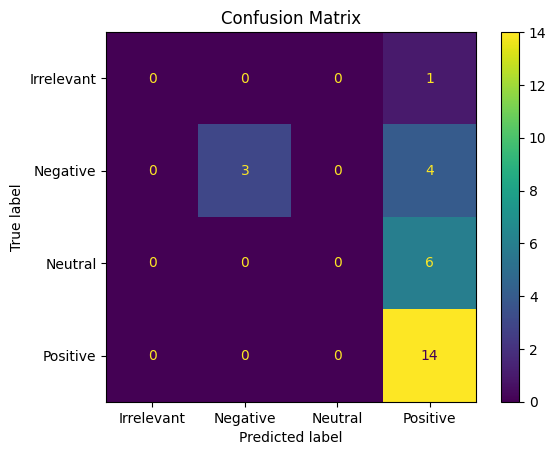

In [ ]:
# Display confusion matrix
cm = confusion_matrix(y_val, preds)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.categories_[0])
plt.figure(figsize=(10, 7))
cm_display.plot()
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


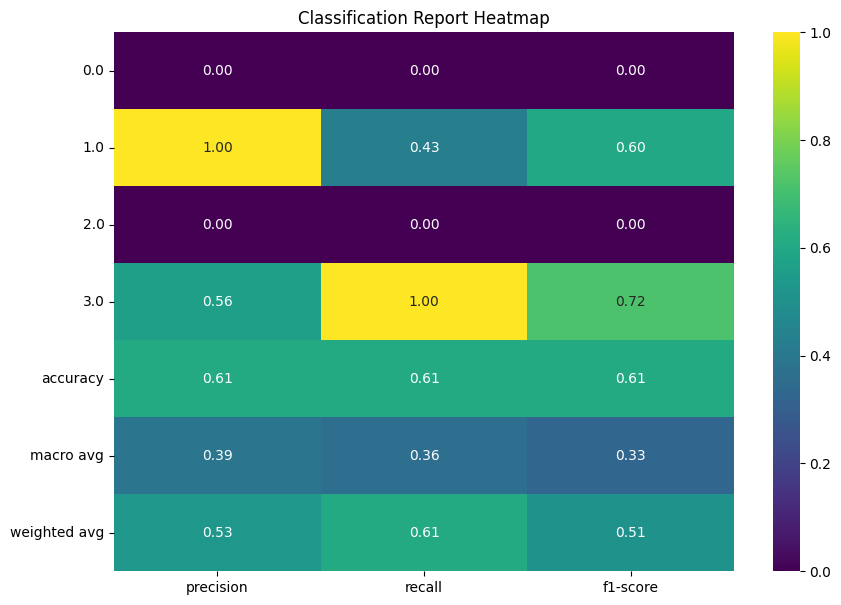

In [ ]:
# Compute classification report and plot heatmap
report = classification_report(y_val, preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(10, 7))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f')
plt.title('Classification Report Heatmap')
plt.show()

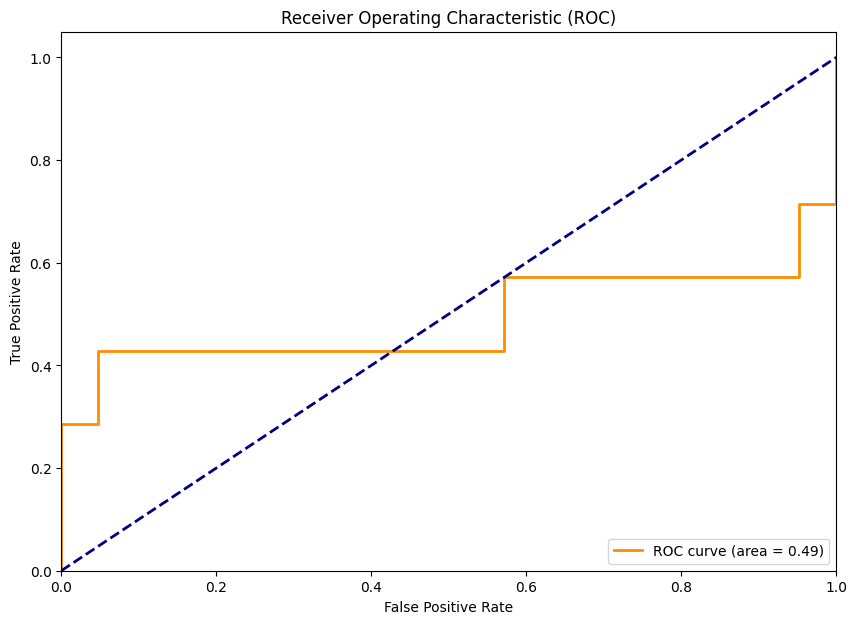

In [ ]:
from sklearn.metrics import roc_curve, auc

# Assuming the positive class label is 1
y_prob = trainer.predict(val_dataset).predictions[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_val, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


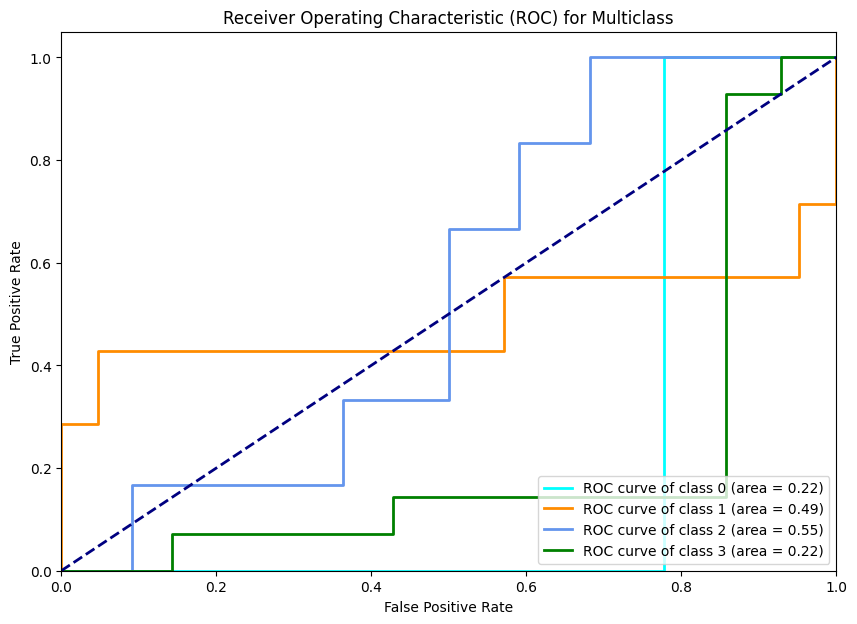

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize the labels for multiclass classification
y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3])  # Adjust based on your classes
y_prob = trainer.predict(val_dataset).predictions

# Compute ROC curve and ROC area for each class
n_classes = y_val_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class %d (area = %0.2f)' % (i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multiclass')
plt.legend(loc="lower right")
plt.show()
